# No Flux Boundary Experiments

## Setup

### Liberaries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import os


### Import custom functions 

In [2]:
from sources.simulation import numerical_solution, euler_maruyama
from sources.plotting import *
from sources.analysis import *
from sources.models import *
from sources.data_storage import *

### Initialization

In [3]:

#defind varaibles

#10 mil
n_parts = 10000000

T = 2
dt = 0.01

n_steps = int(T/ dt)
epsilon = np.sqrt(dt)

#set the boundries
x_bounds = (0, 1)

#drift and diffusion as functions

b = lambda x, t=None: constant_drift(x, t, value=1)
sigma = lambda x, t=None: constant_diffusion(x, t, value=1)


### Initial distribution

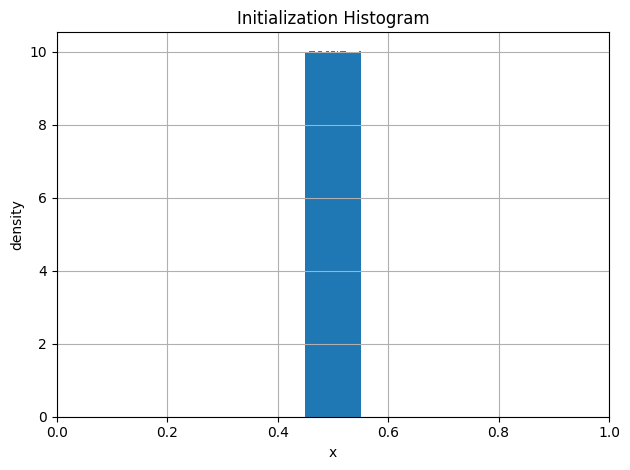

In [4]:
# X_0 = np.random.uniform(bc_1,bc_2, n_parts)
X_0 = np.random.uniform(.45,.55, n_parts)

plot_histogram(X_0, 30, title="Initialization Histogram", x_limit=x_bounds)

plt.tight_layout()
plt.show()

## Experiments

### Compore solutions with reflection, rejection and theta ($\theta =0.5$) boundary conditions

In [5]:


X_ref = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps
                                                     , b=b, sigma=sigma, boundary_type="reflection"
                                                     , boundaries=x_bounds)

X_rej  = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps, b=b, sigma=sigma
                                                     , boundary_type="rejection", boundaries=x_bounds)

X_theta  = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps, b=b, sigma=sigma
                                                     , boundary_type=("theta", 0.5), boundaries=x_bounds)


### Load the data

In [5]:
X_ref = load_solution("ref_b-1_s-1_dt-0.01_N-10000000.npy")
X_rej = load_solution("rej_b-1_s-1_dt-0.01_N-10000000.npy")
X_theta = load_solution("('theta',0.5)_b-1_s-1_dt-0.01_N-10000000.npy")


### Plot the numerical and exact solutions

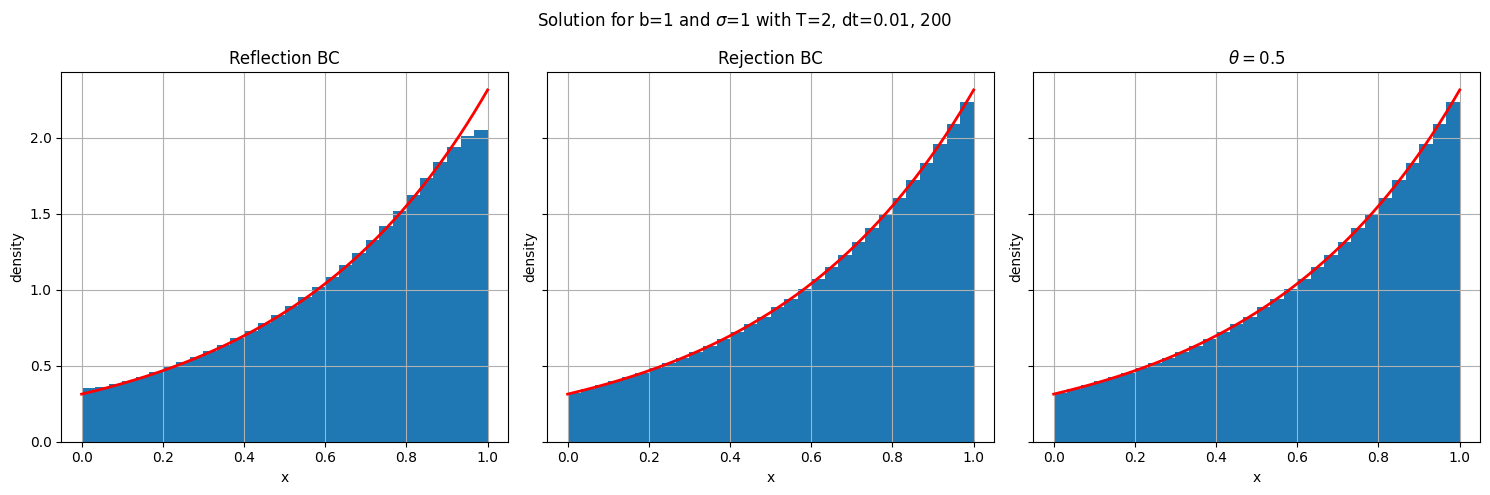

In [6]:
#compute the true solution
x_plot = np.linspace(x_bounds[0], x_bounds[1], 500)
p_exact = stationary_solution(x_plot, b, sigma, x_bounds)

# plot full histogram
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)

fig.suptitle(fr"Solution for b={b(1,1)} and $\sigma$={sigma(1,1)} with {T=}, {dt=}, {n_steps}")

plot_histogram(X=X_ref, bins=30, ax=ax[0], title='Reflection BC',x_label='x', y_label='density', density=True
               , x_limit=None)
ax[0].plot(x_plot, p_exact, "r", linewidth=2)

plot_histogram(X=X_rej, bins=30, ax=ax[1], title='Rejection BC', x_label='x', y_label='density', density=True
               , x_limit=None)
ax[1].plot(x_plot, p_exact, "r", linewidth=2)

plot_histogram(X=X_rej, bins=30, ax=ax[2], title=r'$\theta=0.5$', x_label='x', y_label='density', density=True
               , x_limit=None)
ax[2].plot(x_plot, p_exact, "r", linewidth=2)

plt.tight_layout()
plt.show()



### Boundry Layer Inspection near $x=0$

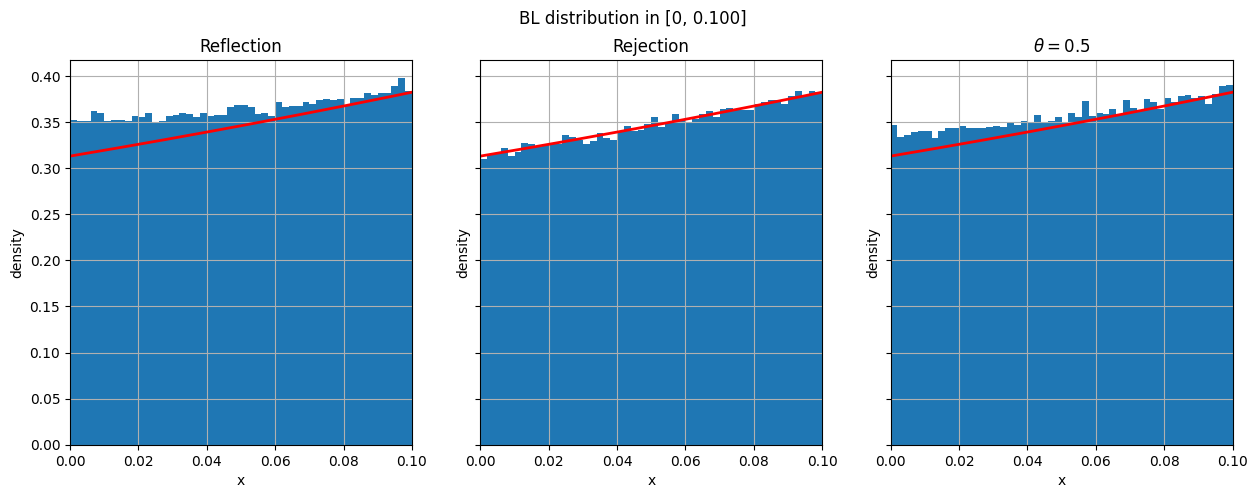

In [7]:
solutions = [X_ref, X_rej, X_theta]
names = ["Reflection", "Rejection", r"$\theta = 0.5$"]

width = epsilon
bins=50

x_plot = np.linspace(x_bounds[0], x_bounds[0] + width, 500)
p_true = stationary_solution(x_plot, b, sigma, x_bounds)

fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
fig.suptitle(f"BL distribution in [{x_bounds[0]}, {x_bounds[0]+width:.3f}]")

for i, X_bc in enumerate(solutions):
    plot_local_density(X=X_bc, x_range=(x_bounds[0], x_bounds[0]+width), bins=bins, ax=ax[i], title=names[i])
    ax[i].plot(x_plot, p_true , "r", linewidth=2, label="True solution")



### Boundry Layer Inspection near $x=1$

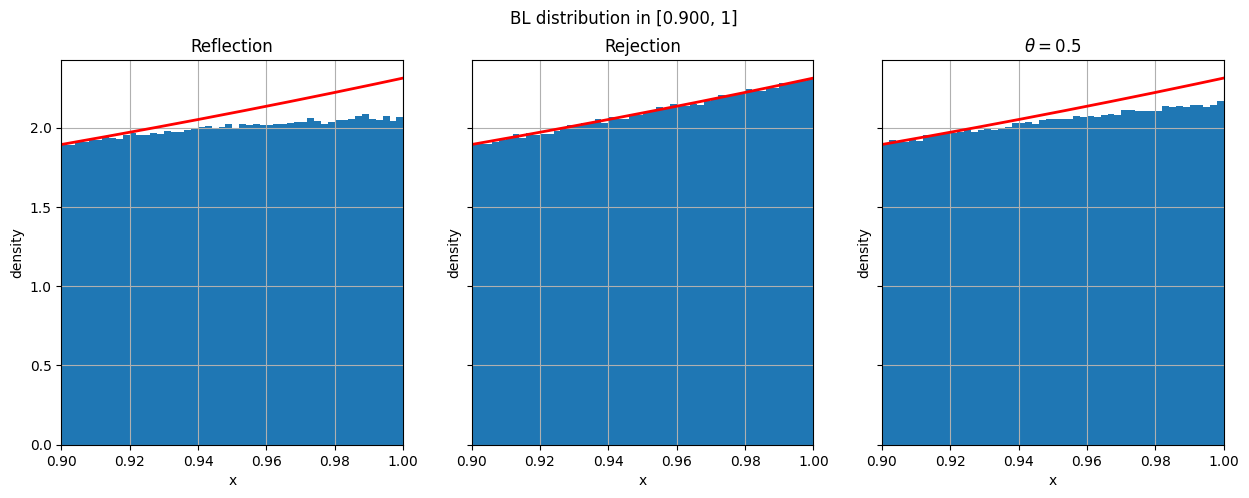

In [8]:
solutions = [X_ref, X_rej, X_theta]
names = ["Reflection", "Rejection", r"$\theta = 0.5$"]

width = epsilon
bins=50

x_plot = np.linspace(x_bounds[1]- width, x_bounds[1], 500)
p_true = stationary_solution(x_plot, b, sigma, x_bounds)

fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
fig.suptitle(f"BL distribution in [{x_bounds[1]-width:.3f}, {x_bounds[1]}]")

for i, X_bc in enumerate(solutions):
    plot_local_density(X=X_bc, x_range=(x_bounds[1]-width, x_bounds[1]), bins=bins, ax=ax[i], title=names[i])
    ax[i].plot(x_plot, p_true , "r", linewidth=2, label="True solution")



### Inspect the error close to $x=1$ (`P(X_ref) - p_true` vs `x`)

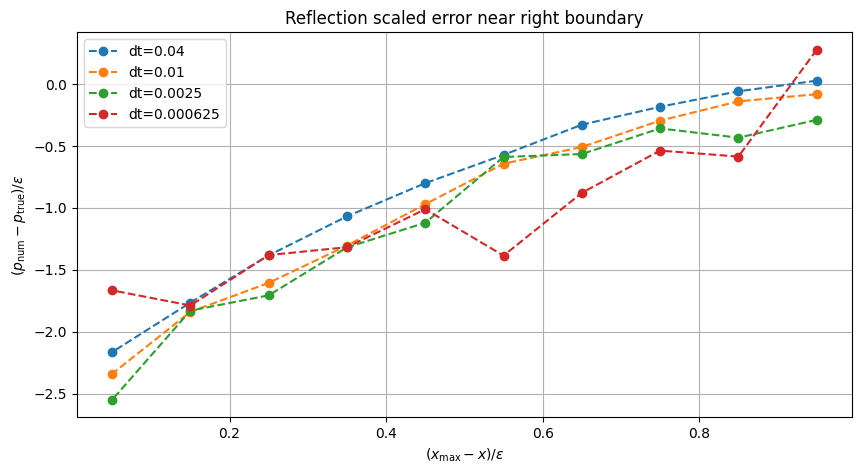

In [ ]:

bins = 10

solutions = ["ref_b-1_s-1_dt-0.04_N-10000000.npy",
             "ref_b-1_s-1_dt-0.01_N-10000000.npy",
             "ref_b-1_s-1_dt-0.0025_N-10000000.npy",
             "ref_b-1_s-1_dt-0.000625_N-10000000.npy"]



plt.figure(figsize=(10, 5))


for solution in solutions:

    X_ref = load_solution(solution)
    dt = float(solution[solution.find("dt-")+3: solution.find("_N")])

    epsilon = np.sqrt(dt)

    x_range = (x_bounds[1] - epsilon, x_bounds[1])

    p_num, centres, counts, edges, bin_widths = histogram_density(X_ref, x_range, bins)

    x_scaled = (x_bounds[1] - centres) / epsilon

    p_true = stationary_solution(centres, b, sigma, x_bounds)
    
    error_scaled = (p_num - p_true) / epsilon
    plt.plot(x_scaled, error_scaled, marker="o", linestyle="--", label=f"dt={dt}")

    


plt.title("Reflection scaled error near right boundary")
plt.xlabel(r"$(x_{\max} - x)/\epsilon$")
plt.ylabel(r"$(p_{\mathrm{num}} - p_{\mathrm{true}})/\epsilon$")
plt.grid(True)
plt.legend()

plt.show()

might need to remove the true (which is related to not having close form for P1 used in this caclucation)\
also, try smaller dt than the last one as it looks noisy or remove it and add a larger value than 0.04
do the same for both ends of the domain. 

### Compute global error (absolute)

dt = 0.04, global error = 0.06647
dt = 0.01, global error = 0.01969
dt = 0.0025, global error = 0.00570
dt = 0.000625, global error = 0.00184


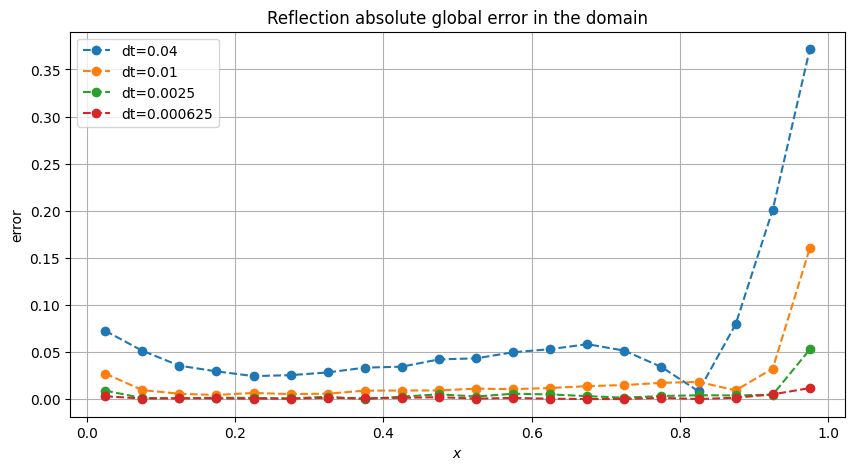

In [21]:
bins = 20

solutions = ["ref_b-1_s-1_dt-0.04_N-10000000.npy",
             "ref_b-1_s-1_dt-0.01_N-10000000.npy",
             "ref_b-1_s-1_dt-0.0025_N-10000000.npy",
             "ref_b-1_s-1_dt-0.000625_N-10000000.npy"]



plt.figure(figsize=(10, 5))


for solution in solutions:

    X_ref = load_solution(solution)
    dt = float(solution[solution.find("dt-")+3: solution.find("_N")])

    x_range = (x_bounds[0], x_bounds[1])

    p_num, centres, counts, edges, bin_widths = histogram_density(X_ref, x_range, bins)

    p_true = stationary_solution(centres, b, sigma, x_bounds)

    global_error, error_per_bin = global_density_error(p_num, p_true, bin_widths)
    
    plt.plot(centres, np.abs(error_per_bin), marker="o", linestyle="--", label=f"dt={dt}")

    print(f"dt = {dt}, global error = {global_error:.5f}")

    


plt.title("Reflection absolute global error in the domain")
plt.xlabel(r"$x$")
plt.ylabel("error")
plt.grid(True)
plt.legend()

plt.show()

dt = 0.04, global error = 0.06647
dt = 0.01, global error = 0.01969
dt = 0.0025, global error = 0.00570
dt = 0.000625, global error = 0.00184


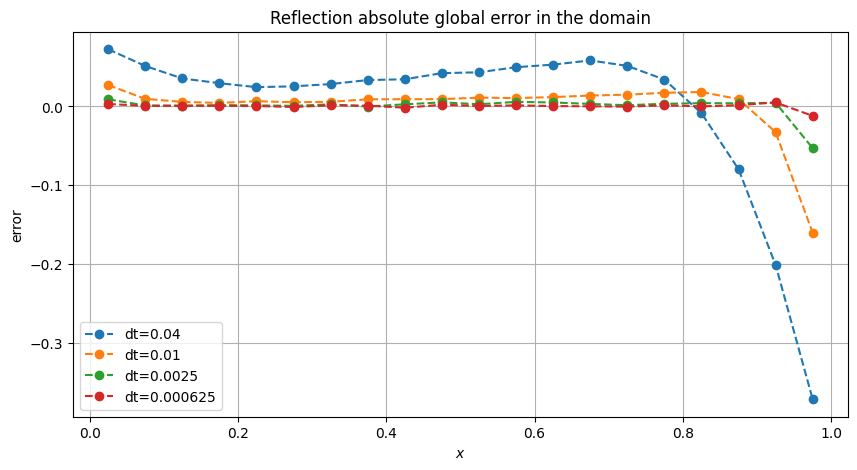

In [20]:
bins = 20

solutions = ["ref_b-1_s-1_dt-0.04_N-10000000.npy",
             "ref_b-1_s-1_dt-0.01_N-10000000.npy",
             "ref_b-1_s-1_dt-0.0025_N-10000000.npy",
             "ref_b-1_s-1_dt-0.000625_N-10000000.npy"]



plt.figure(figsize=(10, 5))


for solution in solutions:

    X_ref = load_solution(solution)
    dt = float(solution[solution.find("dt-")+3: solution.find("_N")])

    x_range = (x_bounds[0], x_bounds[1])

    p_num, centres, counts, edges, bin_widths = histogram_density(X_ref, x_range, bins)

    p_true = stationary_solution(centres, b, sigma, x_bounds)

    global_error, error_per_bin = global_density_error(p_num, p_true, bin_widths)
    
    plt.plot(centres, error_per_bin, marker="o", linestyle="--", label=f"dt={dt}")

    print(f"dt = {dt}, global error = {global_error:.5f}")

    


plt.title("Reflection absolute global error in the domain")
plt.xlabel(r"$x$")
plt.ylabel("error")
plt.grid(True)
plt.legend()

plt.show()

### Convergence

dt = 0.04, epsilon = 0.2, global error = 0.06660
dt = 0.01, epsilon = 0.1, global error = 0.01960
dt = 0.0025, epsilon = 0.05, global error = 0.00684
dt = 0.000625, epsilon = 0.025, global error = 0.00392
estimated order of convergence = 1.378


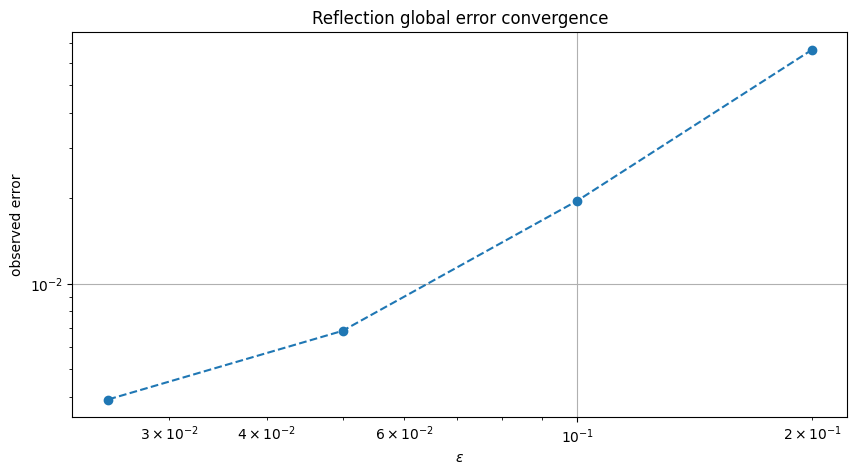

In [7]:
bins = 200

solutions = ["ref_b-1_s-1_dt-0.04_N-10000000.npy",
             "ref_b-1_s-1_dt-0.01_N-10000000.npy",
             "ref_b-1_s-1_dt-0.0025_N-10000000.npy",
             "ref_b-1_s-1_dt-0.000625_N-10000000.npy"]

epsilons = []
global_errors = []

for solution in solutions:

    X_ref = load_solution(solution)
    dt = float(solution[solution.find("dt-")+3: solution.find("_N")])
    epsilon = np.sqrt(dt)

    x_range = (x_bounds[0], x_bounds[1])

    p_num, centres, counts, edges, bin_widths = histogram_density(X_ref, x_range, bins)

    p_true = stationary_solution(centres, b, sigma, x_bounds)

    global_error, error_per_bin = global_density_error(p_num, p_true, bin_widths)

    epsilons.append(epsilon)
    global_errors.append(global_error)

    print(f"dt = {dt}, epsilon = {epsilon}, global error = {global_error:.5f}")


print("=======")
epsilons = np.array(epsilons)
global_errors = np.array(global_errors)
order = np.polyfit(np.log(epsilons), np.log(global_errors), 1)[0]
print(f"estimated order of convergence = {order:.3f}")


plt.figure(figsize=(10, 5))

plt.loglog(epsilons, global_errors, marker="o", linestyle="--")

plt.title("Reflection global error convergence")
plt.xlabel(r"$\epsilon$")
plt.ylabel(r"observed error")
plt.grid(True)

plt.show()

**Note:** above error is probably better be called _observed_ global error because

$error_{observed} =  error_{numerical} + error_{MonteCarlo}$

Also, it seems the number of bins has a decent impact of the error computed as well


### closer look into convergance per $\epsilon$ step


In [49]:
for i in range(len(epsilons)-1):
    error_ratio = global_errors[i] / global_errors[i+1]
    epsilon_ratio = epsilons[i] / epsilons[i+1]
    order = np.log(error_ratio) / np.log(epsilon_ratio)

    print(f"epsilon = {epsilons[i]} to {epsilons[i+1]}, error ratio = {error_ratio:.3f}, order = {order:.3f}")

epsilon = 0.2 to 0.1, error ratio = 3.418, order = 1.773
epsilon = 0.1 to 0.05, error ratio = 3.476, order = 1.797
epsilon = 0.05 to 0.025, error ratio = 2.321, order = 1.214


### small checks for later

In [57]:
bins = 50

solutions = ["ref_b-1_s-1_dt-0.04_N-10000000.npy",
             "ref_b-1_s-1_dt-0.01_N-10000000.npy",
             "ref_b-1_s-1_dt-0.0025_N-10000000.npy",
             "ref_b-1_s-1_dt-0.000625_N-10000000.npy"]

epsilons = []
global_errors = []

for solution in solutions:

    X_ref = load_solution(solution)
    dt = float(solution[solution.find("dt-")+3: solution.find("_N")])

    print(f"For {dt=}:")

    x_range = (x_bounds[0], x_bounds[1])

    print(np.min(X_ref) > x_bounds[0], np.max(X_ref) < x_bounds[1])

    p_num, centres, counts, edges, bin_widths = histogram_density(X_ref, x_bounds, bins)

    p_total = np.sum(p_num * bin_widths)

    print(p_total)

    mean_num = np.mean(X_ref)
    var_num = np.var(X_ref)

    print(f"{mean_num} and {var_num}")
    print("======")



For dt=0.04:
True True
1.0
0.6385107498722501 and 0.06990125524294907
For dt=0.01:
True True
0.9999999999999999
0.6516861844356837 and 0.06911053518905926
For dt=0.0025:
True True
1.0000000000000002
0.6551976453998409 and 0.06900001525139723
For dt=0.000625:
True True
0.9999999999999999
0.6561863224911985 and 0.06903161589649348


## To do next

### find a FP equation with space dependency, generate dataset, and study the BL near it

In [ ]:
### I used this code to compute the theoratical error in boundary side. but it may have been worng
#   all along. I will keep it and give it another try once I implement linear diffusion


# # p at the boundary
# p_0_xmax = stationary_solution(np.array([x_bounds[1]]), b, sigma, x_bounds)[0]

# sigma_prime = 0 #this is for the case of constant diffusion

# X_plot = np.linspace(0, 1 , 200)

# # this is similar to P^(1) as X goes to inf
# P_1 = 2 *(b(0,0)/sigma(0,0)**2) * X_plot * p_0_xmax

# p_true_prime_xmax = stationary_solution_prime(np.array([x_bounds[1]]), b, sigma, x_bounds)[0]

# #this quantitiy is 0 for this problem, need more complicated problem to see diffrent curve
# error_true = P_1 - X_plot* p_true_prime_xmax 


# plt.plot(X_plot, error_true, linestyle="-", label=r"true error")
